In [1]:
import sys
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
sys.path.append(os.path.abspath('../src'))

from models.cnn_model import *

In [2]:
# Path where the .npy files were saved
input_path = "../data/depths/NPY_SPLITS"

# List and sort the files by name
x_files = sorted([f for f in os.listdir(input_path) if f.startswith("X_part") and f.endswith(".npy")])
y_files = sorted([f for f in os.listdir(input_path) if f.startswith("y_part") and f.endswith(".npy")])

# Load and concatenate the parts
X_data = np.concatenate([np.load(os.path.join(input_path, f)) for f in x_files], axis=0)
y_data = np.concatenate([np.load(os.path.join(input_path, f)) for f in y_files], axis=0)

# Print the shape of the loaded arrays
print(f"X_data shape: {X_data.shape}")
print(f"y_data shape: {y_data.shape}")

X_data shape: (430, 387, 450, 3)
y_data shape: (430, 387, 450, 1)


In [3]:
# Split data into training and testing sets
X_train, X_val, y_train, y_val = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

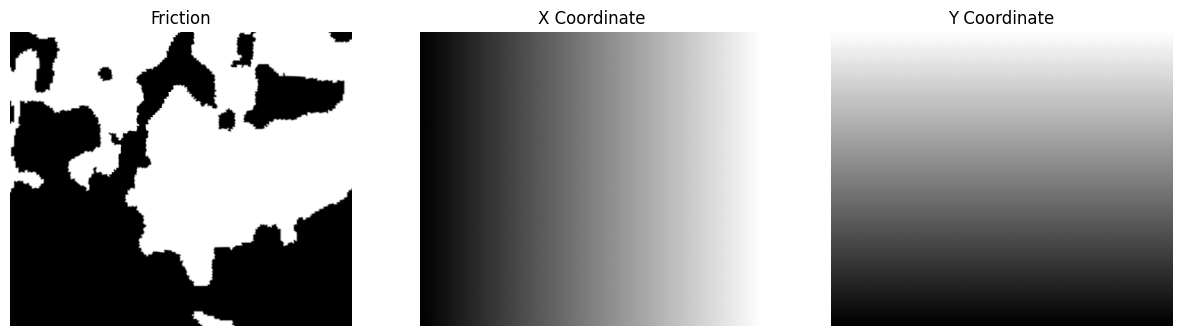

In [4]:
# Select the third image from the training set
sample_image = X_train[2]  # Expected shape: (387, 450, 3)

# Extract the 3 channels: friction, X coordinate, Y coordinate
friction = sample_image[:, :, 0]  # First channel
x_coord = sample_image[:, :, 1]   # Second channel
y_coord = sample_image[:, :, 2]   # Third channel

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot each image with a corresponding title
axes[0].imshow(friction, cmap="gray")
axes[0].set_title("Friction")

axes[1].imshow(x_coord, cmap="gray")
axes[1].set_title("X Coordinate")

axes[2].imshow(y_coord, cmap="gray")
axes[2].set_title("Y Coordinate")

# Remove axes from all images
for ax in axes:
    ax.axis("off")

# Show the figure
plt.show()


In [5]:
correlation_map_train = correlation_weigths(X_train, y_train)
correlation_map_val = correlation_weigths(X_val, y_val)
correlation_map_train = jnp.nan_to_num(correlation_map_train, nan=0.0)
correlation_map_val = jnp.nan_to_num(correlation_map_val, nan=0.0)

In [6]:
# ============================
# Initialize model and optimizer
# ============================
rng = jax.random.PRNGKey(0)
model = CNNModel()
learning_rate = 1e-3
optimizer = optax.adam(learning_rate)

params = model.init(rng, X_train[:1])  # Initialize model with a sample

state = TrainState.create(apply_fn=model.apply, params=params, tx=optimizer)

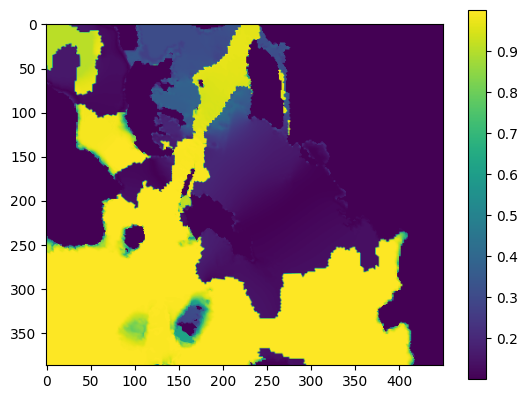

In [7]:
#plt.imshow(create_weight_map(corr_val_batch[1,:,:,1]))
plt.imshow(create_weight_map(correlation_map_train))
plt.colorbar()
plt.show()

In [8]:
# ====================================
# Optimization before training
# ====================================
import gc

# Use float32 to avoid RAM overload
X_train = X_train#.astype(np.float32)
y_train = y_train#.astype(np.float32)
X_val = X_val#.astype(np.float32)
y_val = y_val#.astype(np.float32)
correlation_map_train = correlation_map_train#.astype(np.float32)
correlation_map_val = correlation_map_val#.astype(np.float32)

# Define parameters
epochs = 100
batch_size = 4  # Smaller to avoid memory issues
num_batches = X_train.shape[0] // batch_size
num_val_batches = X_val.shape[0] // batch_size

# Trim dataset to match complete batches
X_train = X_train[:num_batches * batch_size]
y_train = y_train[:num_batches * batch_size]
X_val = X_val[:num_val_batches * batch_size]
y_val = y_val[:num_val_batches * batch_size]

# Preload expanded correlation maps by batch
corr_train_batch = get_correlation_map_batch(correlation_map_train, batch_size)
corr_val_batch = get_correlation_map_batch(correlation_map_train, batch_size)

# ====================================
# Training
# ====================================
loss_history = []
val_loss_history = []

for epoch in range(epochs):
    total_loss = 0.0
    total_val_loss = 0.0

    # Training
    for i in range(num_batches):
        batch_x = X_train[i * batch_size:(i + 1) * batch_size]
        batch_y = y_train[i * batch_size:(i + 1) * batch_size]

        # Paso de entrenamiento
        state, loss = train_step(state, batch_x, batch_y, corr_train_batch)
        total_loss += loss.item()  # Convertir de JAX DeviceArray a float

    # Validation
    for i in range(num_val_batches):
        batch_x_val = X_val[i * batch_size:(i + 1) * batch_size]
        batch_y_val = y_val[i * batch_size:(i + 1) * batch_size]

        val_loss = validation_step(state, batch_x_val, batch_y_val, corr_val_batch)
        total_val_loss += val_loss.item()

    # Save average losses per epoch
    avg_loss = total_loss / num_batches
    avg_val_loss = total_val_loss / num_val_batches
    loss_history.append(avg_loss)
    val_loss_history.append(avg_val_loss)

    print(f"Epoch {epoch+1}, Train Loss: {avg_loss:.5f}, Val Loss: {avg_val_loss:.5f}")

    # Early stopping if validation does not improve
    if len(val_loss_history) > 3 and val_loss_history[-1] >= val_loss_history[-3]:
        print("Early stopping due to lack of validation improvement.")
        break

    # Memory cleanup for safety
    gc.collect()

Epoch 1, Train Loss: 2.03999, Val Loss: 0.12275
Epoch 2, Train Loss: 0.09095, Val Loss: 0.06572
Epoch 3, Train Loss: 0.05834, Val Loss: 0.04668
Epoch 4, Train Loss: 0.04401, Val Loss: 0.03544
Epoch 5, Train Loss: 0.03421, Val Loss: 0.02739
Epoch 6, Train Loss: 0.02690, Val Loss: 0.02676
Epoch 7, Train Loss: 0.01979, Val Loss: 0.01514
Epoch 8, Train Loss: 0.01501, Val Loss: 0.01423
Epoch 9, Train Loss: 0.01263, Val Loss: 0.01073
Epoch 10, Train Loss: 0.01116, Val Loss: 0.00969
Epoch 11, Train Loss: 0.01020, Val Loss: 0.00991
Epoch 12, Train Loss: 0.01011, Val Loss: 0.00889
Epoch 13, Train Loss: 0.00888, Val Loss: 0.00788
Epoch 14, Train Loss: 0.00774, Val Loss: 0.00702
Epoch 15, Train Loss: 0.00724, Val Loss: 0.00695
Epoch 16, Train Loss: 0.00685, Val Loss: 0.00767
Early stopping due to lack of validation improvement.


# Saving the trained model

In [9]:
from flax.training import checkpoints
import os

def save_state(state, ckpt_dir="checkpoints_nn", step=0):
    ckpt_dir_abs = os.path.abspath(ckpt_dir)  # Convertir a ruta absoluta
    os.makedirs(ckpt_dir_abs, exist_ok=True)
    
    checkpoints.save_checkpoint(
        ckpt_dir=ckpt_dir_abs,
        target=state,
        step=step,
        overwrite=True
    )
    print(f"✅ State saved at step {step} in {ckpt_dir_abs}/checkpoint_{step}")

# 💾 Save model state
save_state(state, step=epoch + 1)

✅ State saved at step 16 in D:\Proyectos_GitHub\BayesHydroCNN\notebooks\checkpoints_nn/checkpoint_16


In [10]:
np.random.seed(42)

# Define the subset size (50% of X_train)
subset_size = int(0.5 * X_train.shape[0])

# Select random indices
subset_indices = np.random.choice(X_train.shape[0], subset_size, replace=False)

# Create the X_train subset
X_train_subset = X_train[subset_indices]
y_train_subset = y_train[subset_indices]
correlation_map_train_subset = correlation_map_train[subset_indices]

# Get the batch size and the expected output shape
batch_size = X_train.shape[0]

# Expand and reshape the correlation map for prediction
correlation_map_batch_train = get_correlation_map_batch(correlation_map_train_subset, batch_size)

# Apply the model
y_pred_train_subset = state.apply_fn(state.params, X_train_subset, correlation_map_batch_train)

In [11]:
# Get the batch size and the expected output shape
batch_size = X_val.shape[0]

# Run a forward pass to determine the expected output shape
sample_output = state.apply_fn(state.params, X_val[:1], jnp.zeros((1, 387, 450, 1)))
output_shape = sample_output.shape  # (1, 392, 456, 1) for example

# Expand and reshape the correlation map for prediction
correlation_map_batch_val = get_correlation_map_batch(correlation_map_val, batch_size)

# Apply the model
y_pred_test = state.apply_fn(state.params, X_val, correlation_map_batch_val)

In [12]:
from models.cnn_model import *
from utils.visualization import *

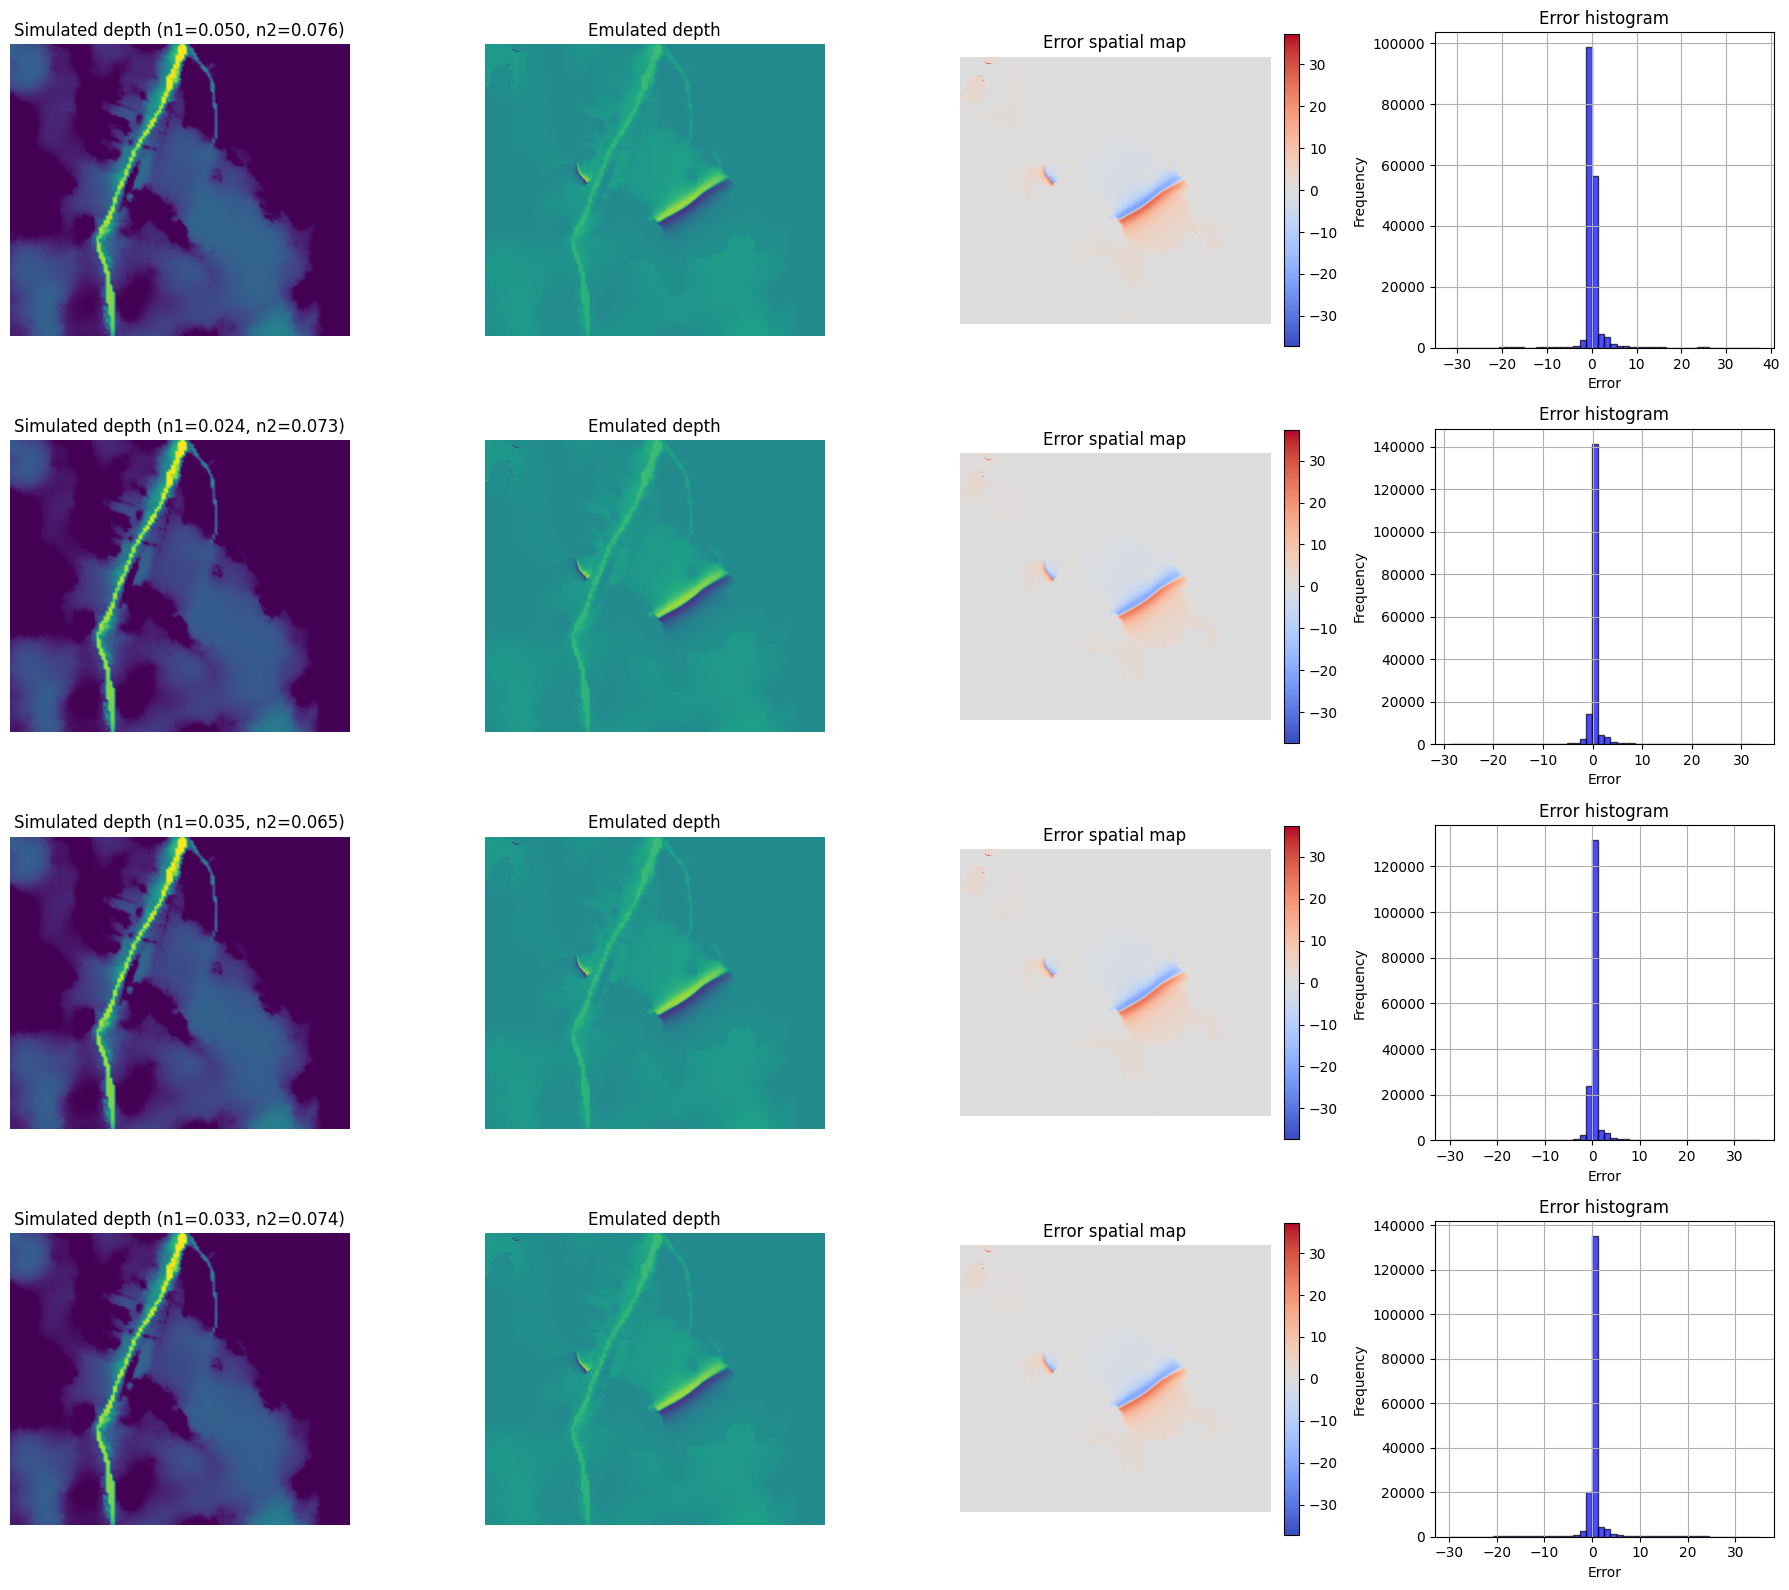

In [13]:
# Select 4 random images from the validation set
num_samples = 4
indices = np.random.choice(X_val.shape[0], num_samples, replace=False)

# Convert from JAX tensor to NumPy for visualization
y_pred_np = np.array(y_pred_test)  # Predictions
y_test_np = np.array(y_val)        # Ground truth

# Compute the difference between the true and predicted images
difference = y_test_np - y_pred_np

# Retrieve roughness values (n1, n2) for each selected image
roughness_values = get_n1_n2(X_val, indices)

# Create a figure with 4 rows and 4 columns (16 subplots total)
fig, axes = plt.subplots(4, 4, figsize=(18, 16))

for i, idx in enumerate(indices):
    # Extract image from the validation set
    sample_image = X_val[idx]  # Expected shape: (height, width, 3)

    # Extract the friction channel
    friction = sample_image[:, :, 0]  # First channel = friction

    # Get roughness values (n1, n2) for this image
    n1, n2 = roughness_values[i]  # ✅ Changed from idx to i

    # Compute the standard deviation of the error
    error_values = difference[idx, :, :, 0].flatten()  # Flatten errors
    std_dev = np.std(error_values)  # Standard deviation

    # Subplot row position
    row = i  # Image row

    # 1️⃣ **Ground Truth Image**
    axes[row, 0].imshow(y_test_np[idx, :, :, 0], cmap="viridis")
    axes[row, 0].set_title(f"Simulated depth (n1={n1:.3f}, n2={n2:.3f})")
    axes[row, 0].axis("off")

    # 2️⃣ **Predicted Image**
    axes[row, 1].imshow(y_pred_np[idx, :, :, 0], cmap="viridis")
    axes[row, 1].set_title("Emulated depth")
    axes[row, 1].axis("off")

    # 3️⃣ **Difference between Ground Truth and Prediction**
    im1 = axes[row, 2].imshow(difference[idx, :, :, 0], cmap="coolwarm", 
                              vmin=-np.max(abs(difference)), vmax=np.max(abs(difference)))
    axes[row, 2].set_title("Error spatial map")
    fig.colorbar(im1, ax=axes[row, 2], fraction=0.046, pad=0.04)
    axes[row, 2].axis("off")

    # 4️⃣ **Error Histogram**
    axes[row, 3].hist(error_values, bins=50, color='blue', edgecolor='black', alpha=0.7)
    axes[row, 3].set_xlabel("Error")
    axes[row, 3].set_ylabel("Frequency")
    axes[row, 3].set_title("Error histogram")
    axes[row, 3].grid(True)

# Adjust layout
plt.tight_layout()

# Save the figure
plt.savefig("subplots_results.png", dpi=300)

# Display the figure
plt.show()